<a href="https://colab.research.google.com/github/aedenj/continuous-improvement/blob/main/classes/ece-512-graphical-models/lecture-one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 1 in Code

In [1]:
!pip install networkx[default]

## Supervised Machine Learning: Generalizing Associative Memories

In [1]:
from sympy import symbols, Eq, solve, init_printing
init_printing()

x = symbols('x')
eq = Eq(x**2 + 2*x + 1, 0)
display(eq)


 2              
x  + 2⋅x + 1 = 0

Suppose we are given a dataset $D = \{(x^{(i)}, y^{(i)})\}_{i=1}^n$, of n samples and a loss function $\quad \ell(x, y) \in \mathbb{R}^{+}$ that expresses badness about predicting x as y, where domain of x (resp. y) is X (resp. Y).




## Graphs

In [2]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from([1,2,3])
G.add_edges_from([(1,2),(1,3)])

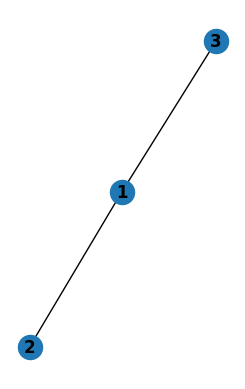

In [3]:
import matplotlib.pyplot as plt

subax1 = plt.subplot(121)
nx.draw(G, with_labels=True, font_weight='bold')

In [4]:
A = nx.adjacency_matrix(G)
A.toarray()

array([[0, 1, 1],
       [1, 0, 0],
       [1, 0, 0]])

### Two Moons

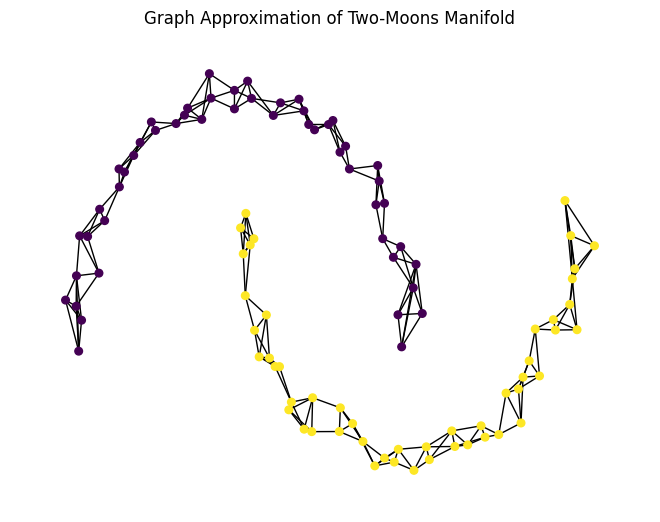

In [38]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors


X, y = make_moons(n_samples=100, noise=0.05, random_state=42)
G = nx.Graph()
for i, pos in enumerate(X):
    G.add_node(i, pos=pos, label=y[i])


nn = NearestNeighbors(n_neighbors=5)
nn.fit(X)
distances, indices = nn.kneighbors(X)

for u, neighbors in enumerate(indices):
    for j, v in enumerate(neighbors[1:]):
        G.add_edge(u, v, weight=distances[u][j+1])


pos = {i: X[i] for i in range(len(X))}
nx.draw(G, pos, node_color=y, node_size=30)
plt.title("Graph Approximation of Two-Moons Manifold")
plt.show()